# Parametric PCA-MNIST exact-polar Muon experiment

This notebook can run a quick smoke test or reproduce the full experiment. The main parameter cell exposes `n_train`, PCA dimension and whitening, teacher rank, student width, fixed learning rate, steps, seed lists, and analysis windows.

In [1]:
from pathlib import Path
import copy
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "mnist_pca_muon.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import mnist_pca_muon as mpm
import pandas as pd
from IPython.display import Image, display

print("Bundle root:", ROOT)

Bundle root: /mnt/data/mnist_pca_muon_parametric_bundle


## 1. Parameters

In [2]:
# ------------------------ EDIT THIS CELL ------------------------
PRESET = "smoke"              # "smoke" or "reproduction"
RUN_CONFIRMATION = False       # True for all 30 confirmation seeds
FORCE_REBUILD_PROBLEM = True
FORCE_RERUN = True

source_candidates = [
    ROOT / "data" / "mnist_muon.zip",
    Path("/mnt/data/mnist_muon.zip"),
]
MNIST_SOURCE = next((p for p in source_candidates if p.exists()), source_candidates[0])

config = mpm.load_config(ROOT / "configs" / f"{PRESET}.json")
config["data"]["mnist_source"] = str(MNIST_SOURCE)
config["output"]["output_root"] = str(ROOT / "notebook_outputs")
config["output"]["experiment_name"] = f"notebook_{PRESET}"

# Main editable parameters.
if PRESET == "reproduction":
    config["data"]["n_train"] = 5000
    config["data"]["pca_dim"] = 100
    config["data"]["whiten"] = True
    config["teacher"]["rank"] = 4
    config["teacher"]["seed"] = 5
    config["student"]["width"] = 50
    config["student"]["learning_rate"] = 0.60
    config["student"]["steps"] = 1500
    config["student"]["log_every"] = 10
    config["analysis"]["primary_window"] = [60, 240]
else:
    config["data"]["n_train"] = 600
    config["data"]["pca_dim"] = 20
    config["teacher"]["rank"] = 2
    config["student"]["width"] = 12
    config["student"]["learning_rate"] = 0.40
    config["student"]["steps"] = 50
    config["student"]["log_every"] = 5
    config["analysis"]["primary_window"] = [10, 30]

# Further examples:
# config["data"]["allowed_digits"] = [0, 1, 2, 3]
# config["teacher"]["head_value"] = 0.5
# config["student"]["head_value"] = 0.1  # None => 1/sqrt(PCA dimension)
# config["seeds"]["development"] = [1, 2, 3]
# config["seeds"]["confirmation"] = [101, 103, 107]

mpm.validate_config(config)
config

{'data': {'mnist_source': '/mnt/data/mnist_muon.zip',
  'archive_member': 'mnist_muon/mnist.npz',
  'images_key': 'Xa',
  'labels_key': 'ya',
  'n_train': 600,
  'pca_dim': 20,
  'whiten': True,
  'problem_seed': 2026,
  'allowed_digits': None,
  'pixel_scale': 255.0},
 'teacher': {'rank': 2, 'seed': 5, 'head_value': 1.0},
 'student': {'width': 12,
  'head_value': None,
  'learning_rate': 0.4,
  'steps': 50,
  'log_every': 5,
  'log_both_phases': True,
  'threads': 1,
  'checkpoint_steps': [0, 10, 30, 49]},
 'seeds': {'development': [1, 2], 'confirmation': []},
 'analysis': {'primary_window': [10, 30],
  'windows': {'60_240': [60, 240],
   '240_400': [240, 400],
   '400_700': [400, 700],
   '700_1000': [700, 1000],
   '1000_1200': [1000, 1200],
   '1200_1490': [1200, 1490],
   '60_400': [60, 400],
   '60_700': [60, 700],
   '60_1000': [60, 1000],
   '60_1490': [60, 1490],
   '10_30': [10, 30],
   '20_40': [20, 40]},
  'bootstrap_repetitions': 500,
  'plot_xmax': 49},
 'output': {'exper

## 2. Prepare the fixed problem

In [3]:
problem_path = mpm.prepare_problem(config, force=FORCE_REBUILD_PROBLEM)
problem = mpm.load_problem(problem_path)
print("Problem:", problem_path)
print("X:", problem["X"].shape)
print("Teacher basis:", problem["U_teacher"].shape)
pd.read_csv(problem_path.with_name("problem_summary.csv"))

Problem: /mnt/data/mnist_pca_muon_parametric_bundle/notebook_outputs/notebook_smoke/fixed_problem.npz
X: (600, 20)
Teacher basis: (20, 2)


,n_train,raw_dimension,pca_dimension,whiten,teacher_rank,mean_coordinate_variance,mean_coordinate_fourth_moment,median_coordinate_fourth_moment,minimum_coordinate_fourth_moment,maximum_coordinate_fourth_moment,gaussian_fourth_moment
0,600,784,20,True,2,0.998333,3.040886,3.057442,2.451984,3.556605,3.0


## 3. Train students

The full-batch update is $W_{t+1}=W_t-\eta\,\mathrm{Polar}(\nabla_W L(W_t))$. The head is fixed.

In [4]:
groups = ("development", "confirmation") if RUN_CONFIRMATION else ("development",)
run_outputs = mpm.run_experiment(
    config,
    groups=groups,
    rebuild_problem=False,
    force_runs=FORCE_RERUN,
)
run_outputs

development 01/2 seed=1: 0.04s


development 02/2 seed=2: 0.01s


{'experiment_dir': PosixPath('/mnt/data/mnist_pca_muon_parametric_bundle/notebook_outputs/notebook_smoke'),
 'problem': PosixPath('/mnt/data/mnist_pca_muon_parametric_bundle/notebook_outputs/notebook_smoke/fixed_problem.npz'),
 'raw_development': PosixPath('/mnt/data/mnist_pca_muon_parametric_bundle/notebook_outputs/notebook_smoke/raw_development')}

## 4. Analyze the loss cycle and both alignment phases

In [5]:
analysis_outputs = mpm.analyze_experiment(config, groups=groups)
summary = pd.read_csv(analysis_outputs["summary"])
summary

,group,window,start,end,n_seeds,median_loss_change,loss_change_ci_low,loss_change_ci_high,median_mean_even_start,mean_even_start_ci_low,mean_even_start_ci_high,median_mean_even_end,mean_even_end_ci_low,mean_even_end_ci_high,median_mean_even_gain,mean_even_gain_ci_low,mean_even_gain_ci_high,median_mean_odd_start,mean_odd_start_ci_low,mean_odd_start_ci_high,median_mean_odd_end,mean_odd_end_ci_low,mean_odd_end_ci_high,median_mean_odd_gain,mean_odd_gain_ci_low,mean_odd_gain_ci_high,median_mean_phaseavg_start,mean_phaseavg_start_ci_low,mean_phaseavg_start_ci_high,median_mean_phaseavg_end,mean_phaseavg_end_ci_low,mean_phaseavg_end_ci_high,median_mean_phaseavg_gain,mean_phaseavg_gain_ci_low,mean_phaseavg_gain_ci_high,median_min_even_start,min_even_start_ci_low,min_even_start_ci_high,median_min_even_end,min_even_end_ci_low,min_even_end_ci_high,median_min_even_gain,min_even_gain_ci_low,min_even_gain_ci_high,median_min_odd_start,min_odd_start_ci_low,min_odd_start_ci_high,median_min_odd_end,min_odd_end_ci_low,min_odd_end_ci_high,median_min_odd_gain,min_odd_gain_ci_low,min_odd_gain_ci_high,median_min_phaseavg_start,min_phaseavg_start_ci_low,min_phaseavg_start_ci_high,median_min_phaseavg_end,min_phaseavg_end_ci_low,min_phaseavg_end_ci_high,median_min_phaseavg_gain,min_phaseavg_gain_ci_low,min_phaseavg_gain_ci_high,median_rho2,rho2_ci_low,rho2_ci_high,median_r2,r2_ci_low,r2_ci_high,positive_mean_even_seeds,positive_mean_odd_seeds,positive_min_even_seeds,positive_min_odd_seeds,loss_within_5pct_seeds
0,development,10_30,10,30,2,0.111640,-0.053074,0.276354,0.976555,0.971717,0.981393,0.982058,0.973075,0.991041,0.005503,0.001359,0.009648,0.981574,0.980699,0.982450,0.989088,0.984497,0.993679,0.007514,0.003798,0.01123,0.979065,0.976208,0.981922,0.985573,0.978786,0.992360,0.006508,0.002578,0.010439,0.968782,0.964725,0.972838,0.974392,0.961551,0.987232,0.005610,-0.003174,0.014394,0.968061,0.965930,0.970192,0.981626,0.973101,0.990151,0.013565,0.007172,0.019958,0.968421,0.965328,0.971515,0.978009,0.967326,0.988691,0.009587,0.001999,0.017176,0.996491,0.994091,0.998890,0.52284,0.367235,0.678446,2,2,1,2,0
1,development,20_40,20,40,2,0.009491,0.000095,0.018888,0.981380,0.972488,0.990272,0.983361,0.975123,0.991598,0.001981,0.001327,0.002635,0.988482,0.983960,0.993004,0.990390,0.986949,0.993830,0.001908,0.000826,0.00299,0.984931,0.978224,0.991638,0.986875,0.981036,0.992714,0.001944,0.001076,0.002812,0.975240,0.964362,0.986117,0.977009,0.965990,0.988027,0.001769,0.001628,0.001910,0.980770,0.972213,0.989327,0.984136,0.977923,0.990349,0.003366,0.001022,0.005710,0.978005,0.968288,0.987722,0.980572,0.971957,0.989188,0.002567,0.001466,0.003669,0.999450,0.999150,0.999751,0.48714,0.295835,0.678446,2,2,2,2,2


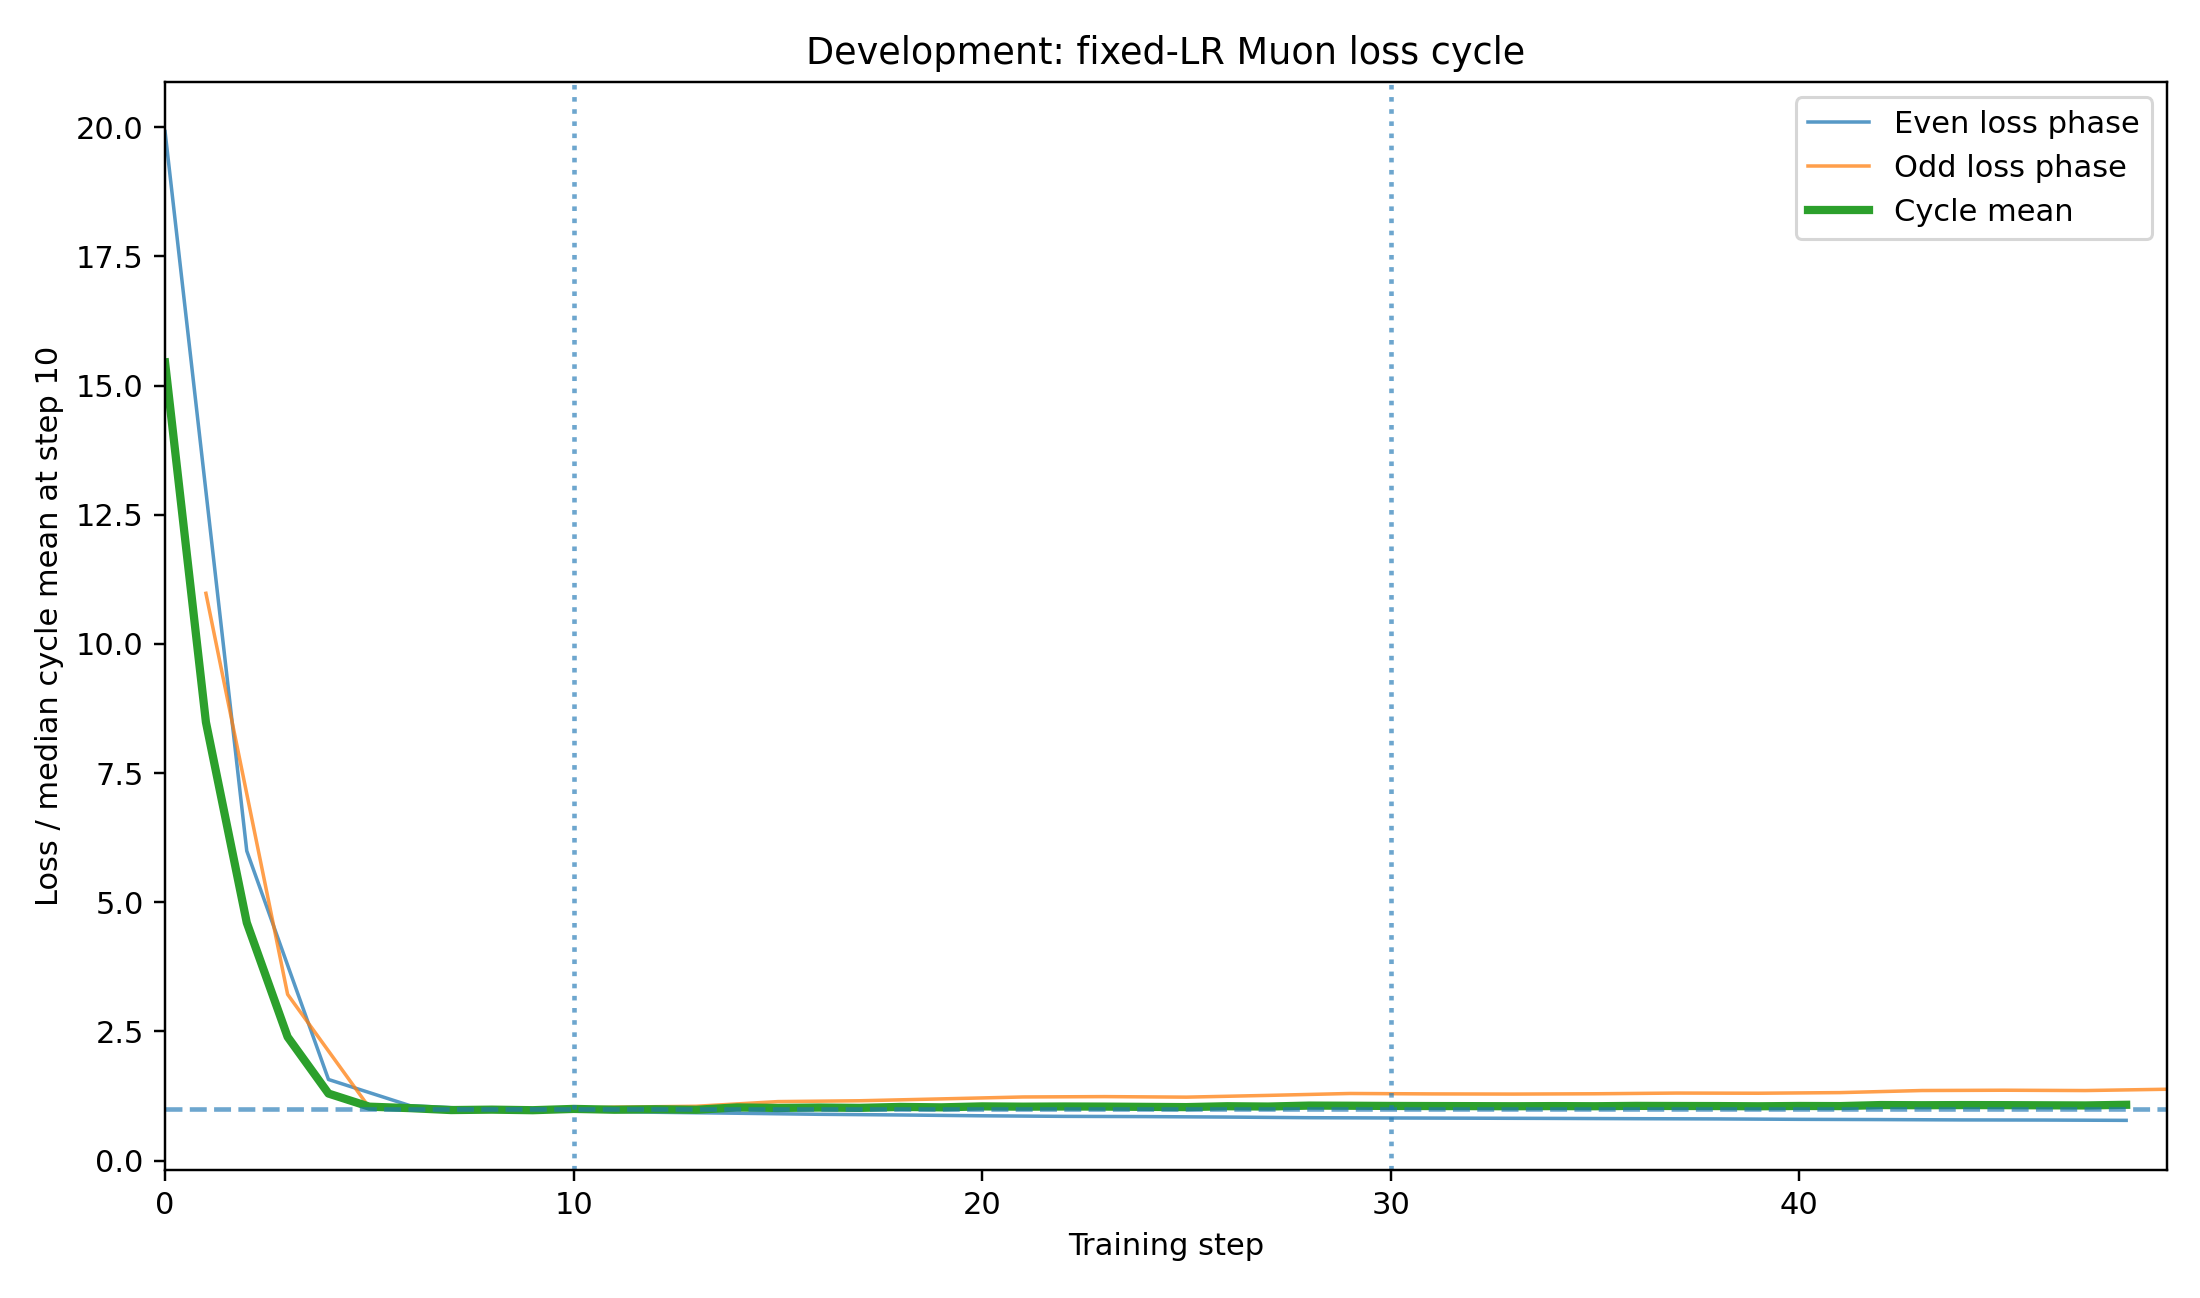

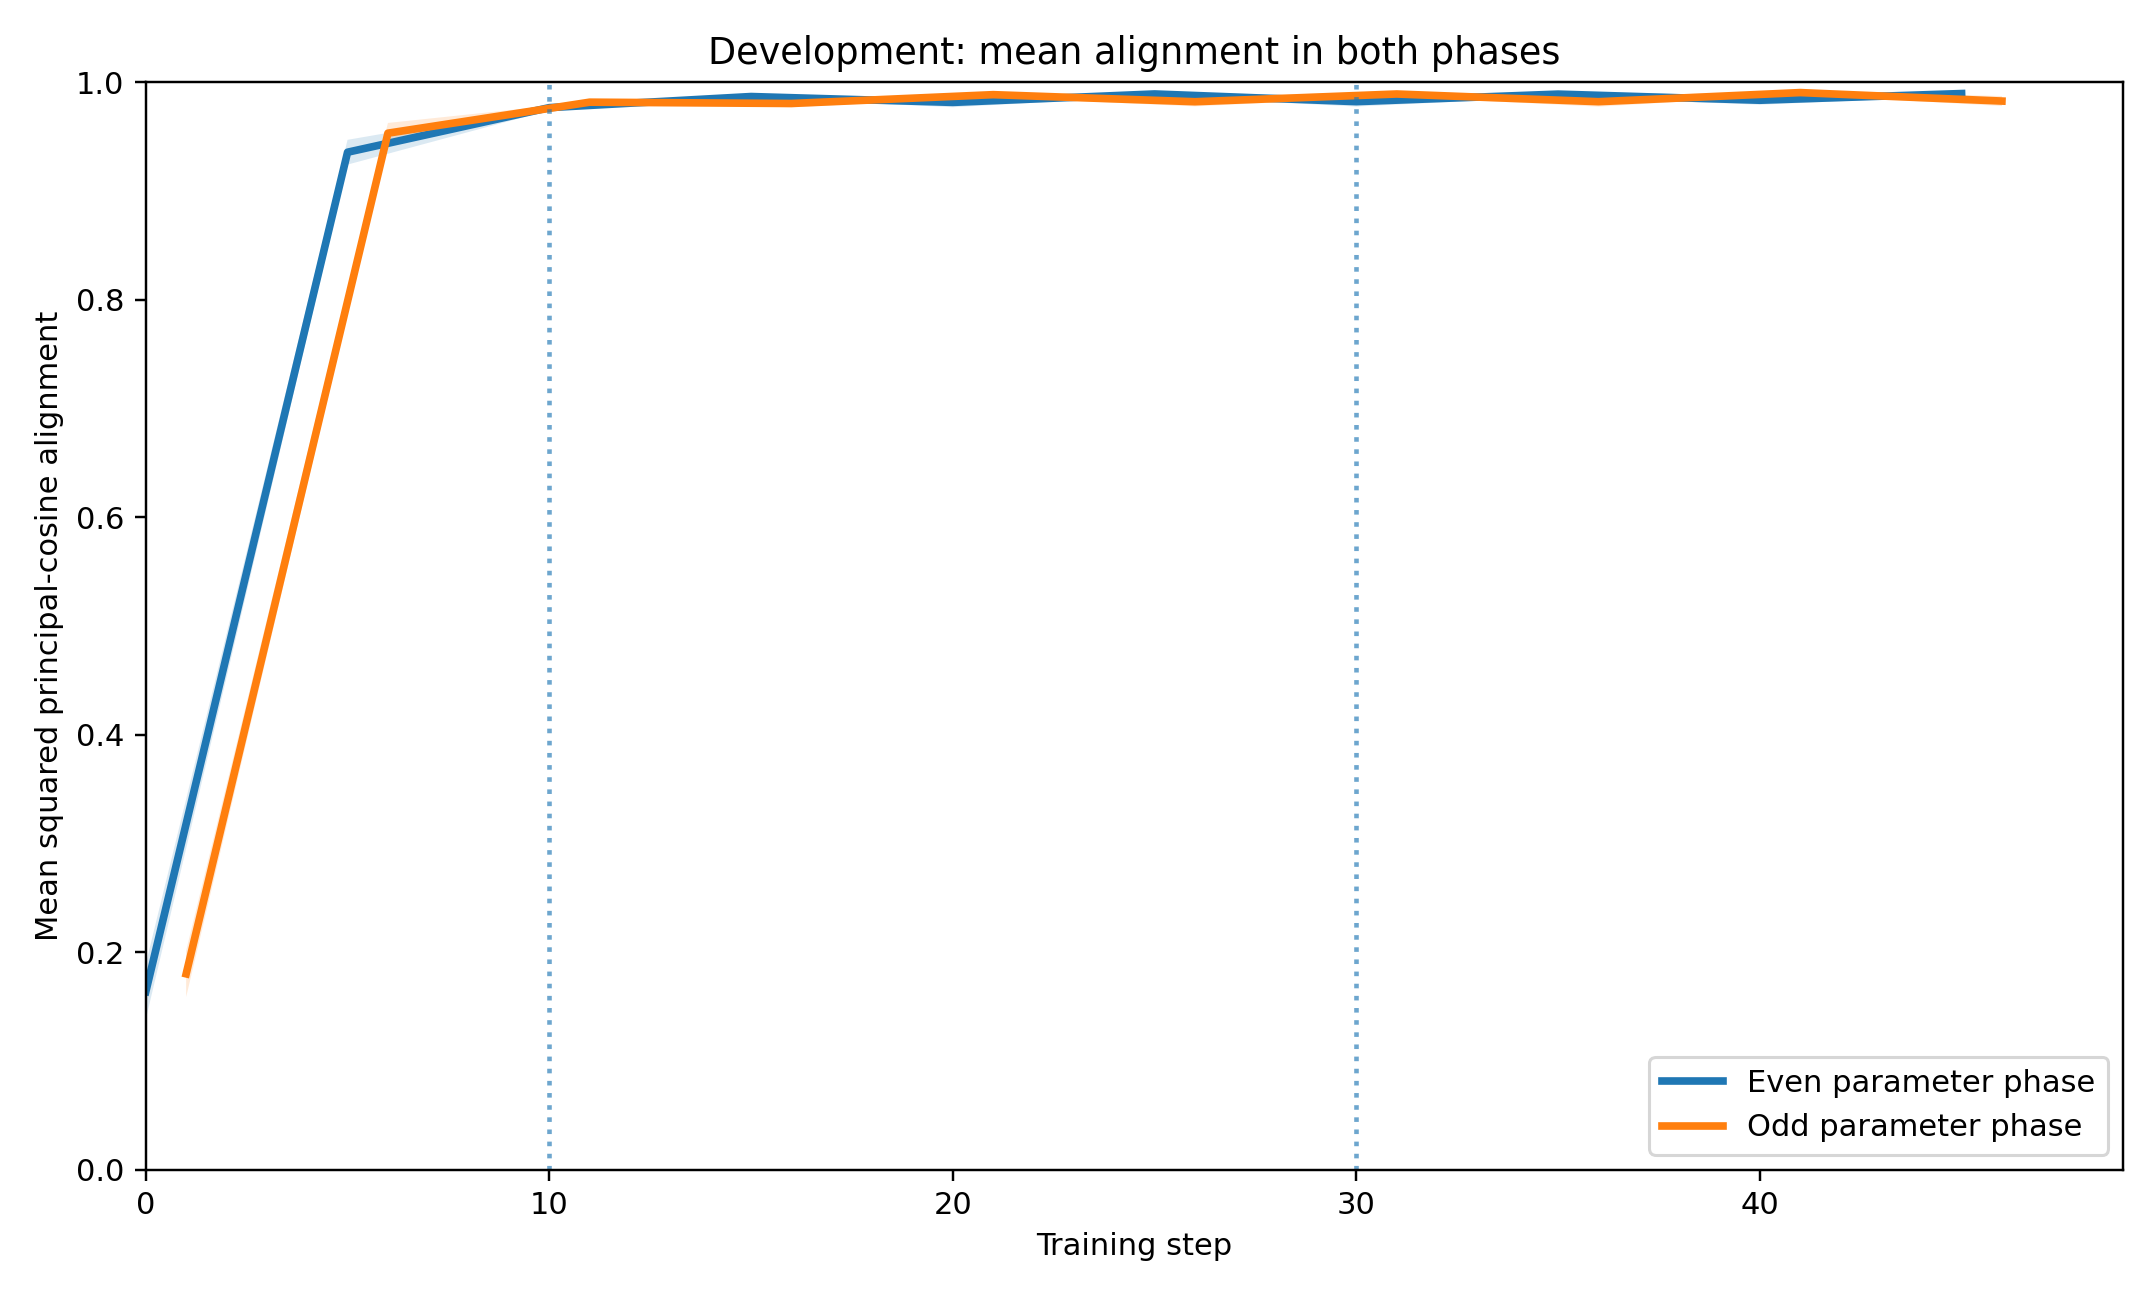

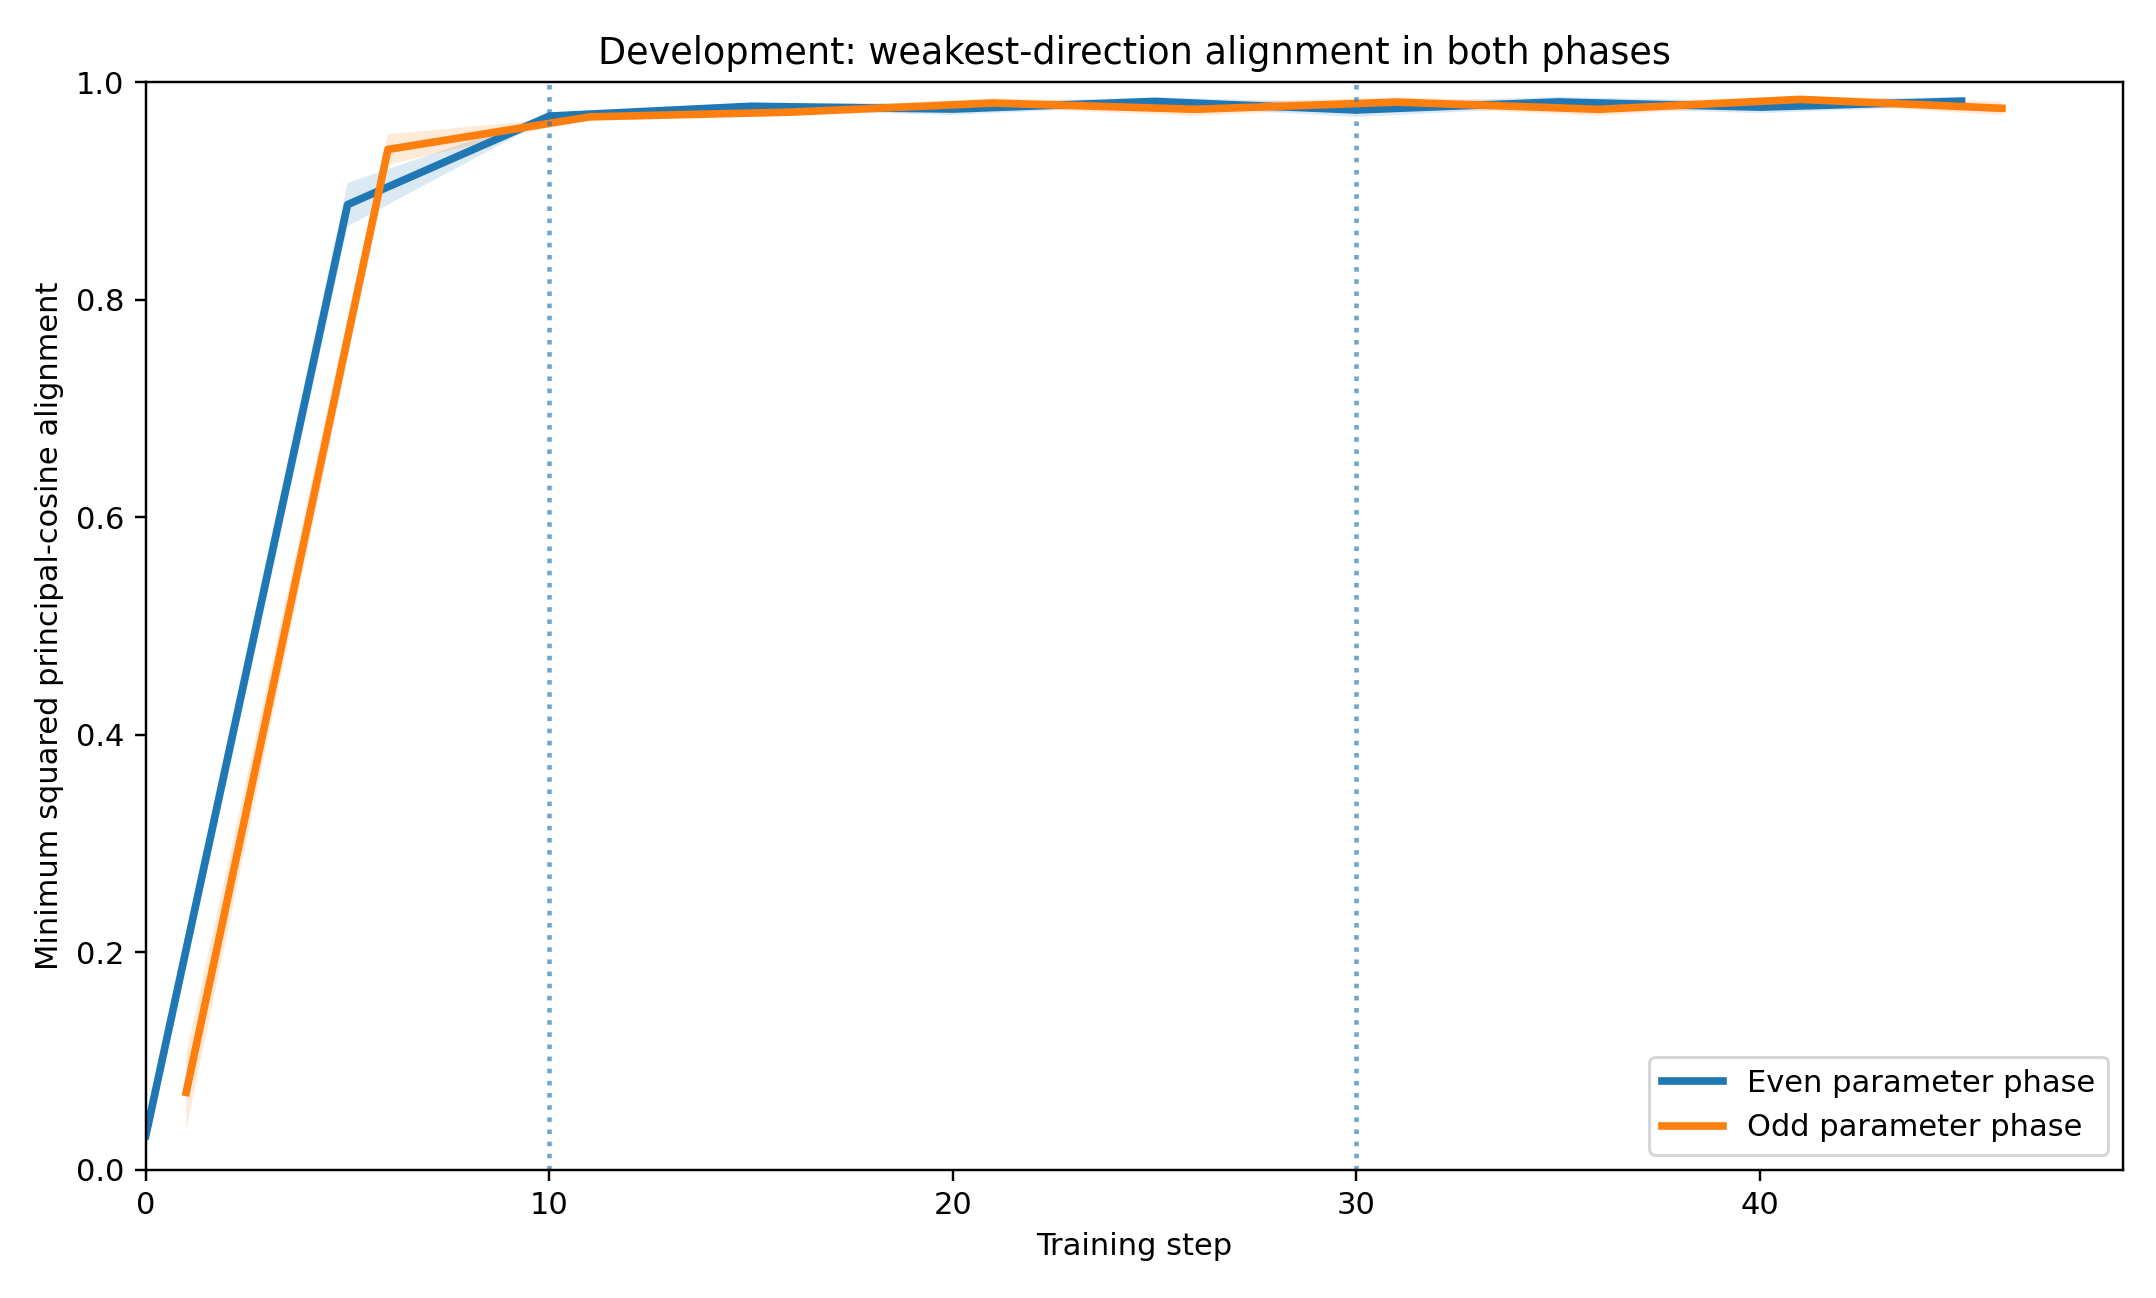

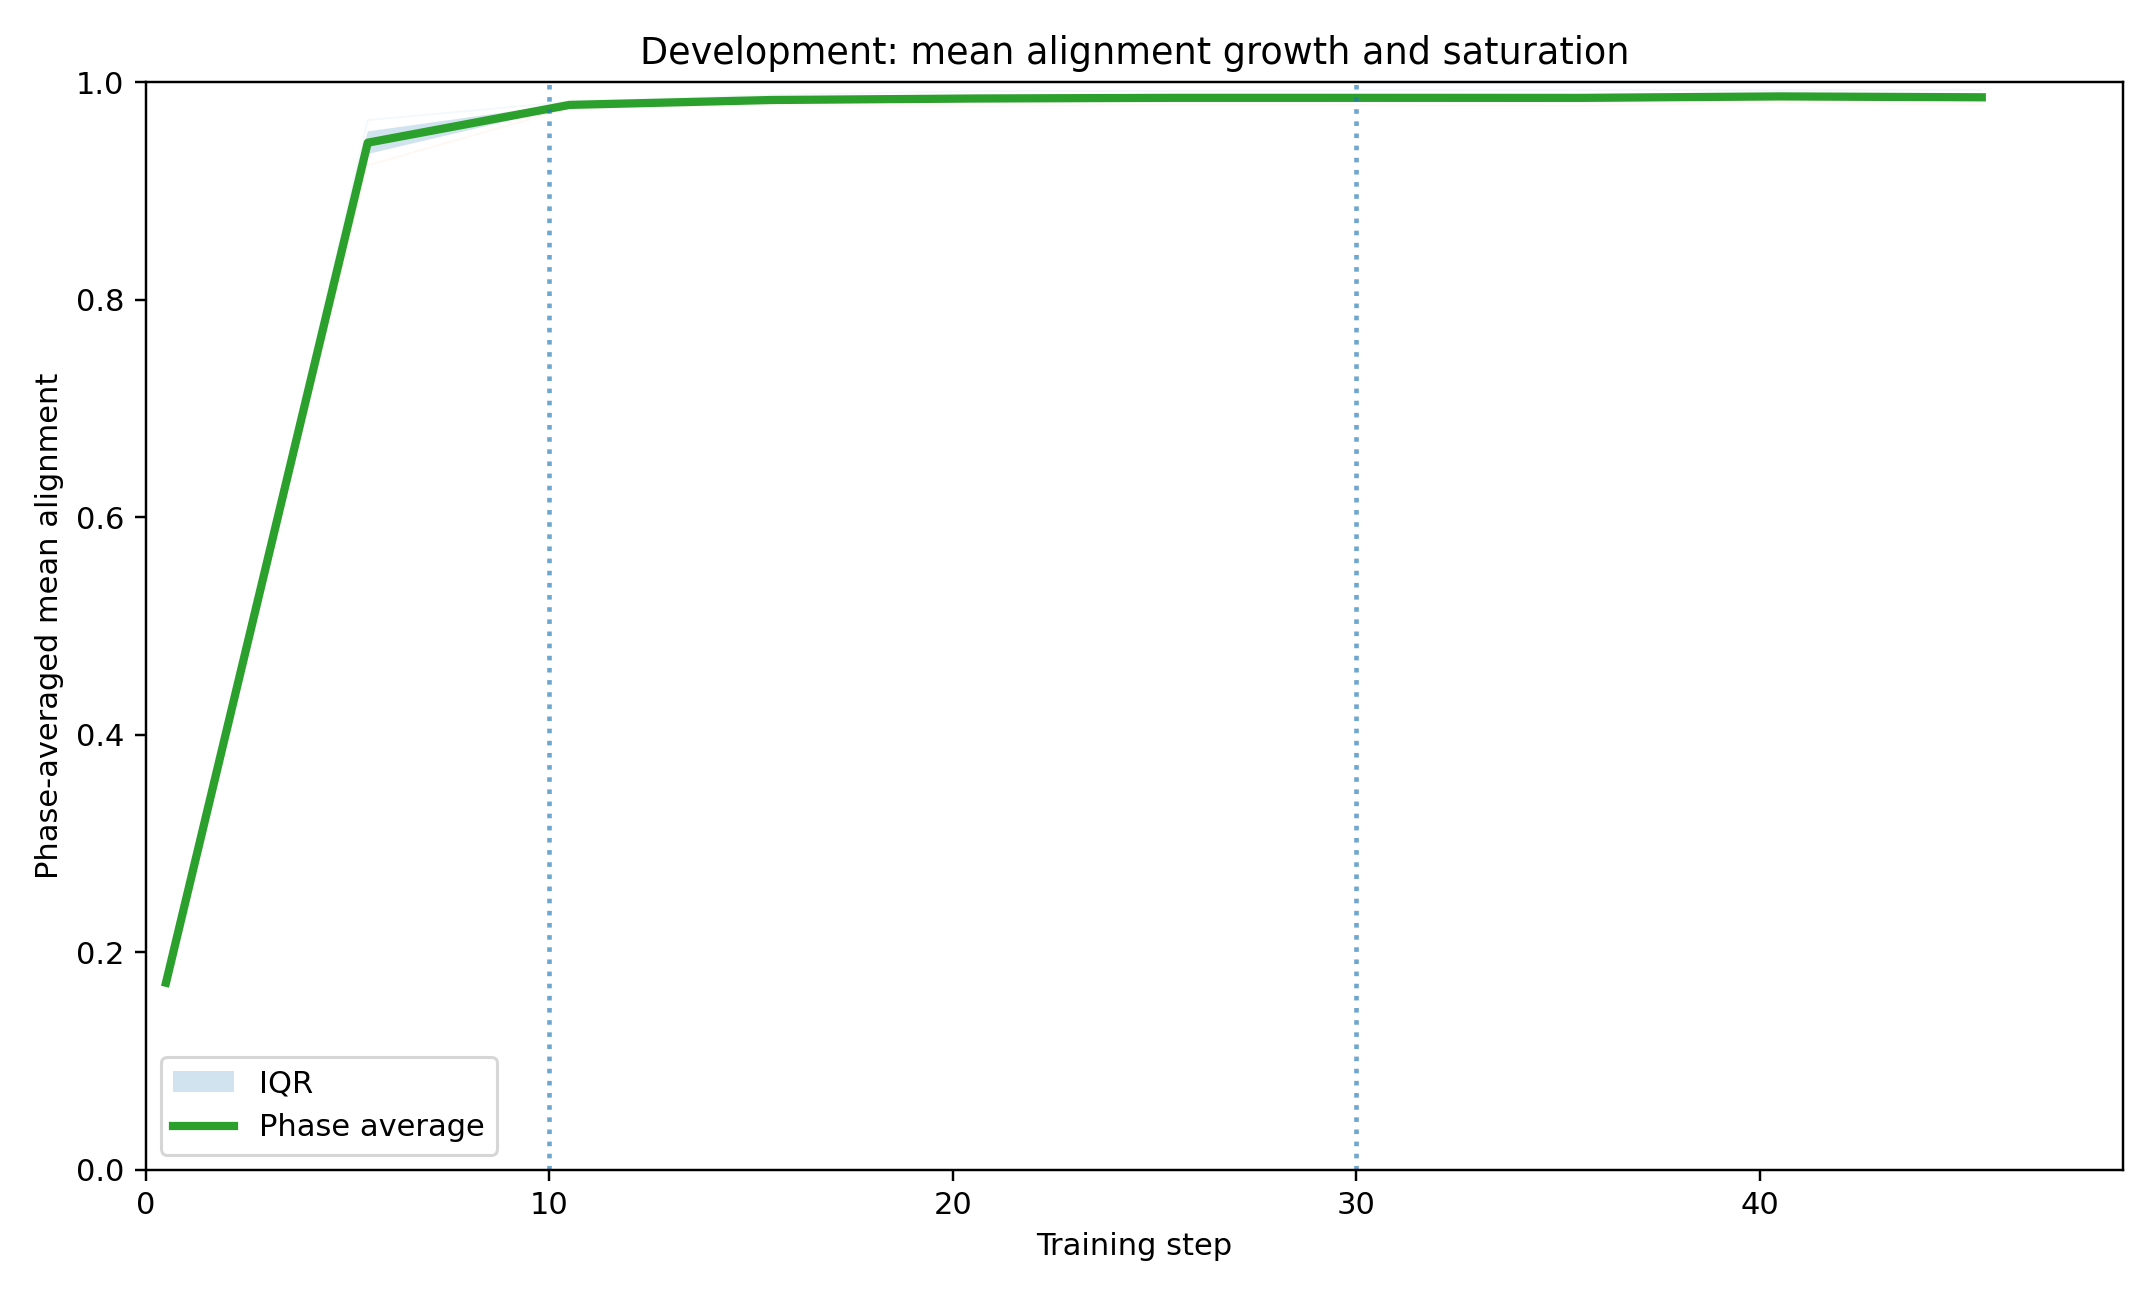

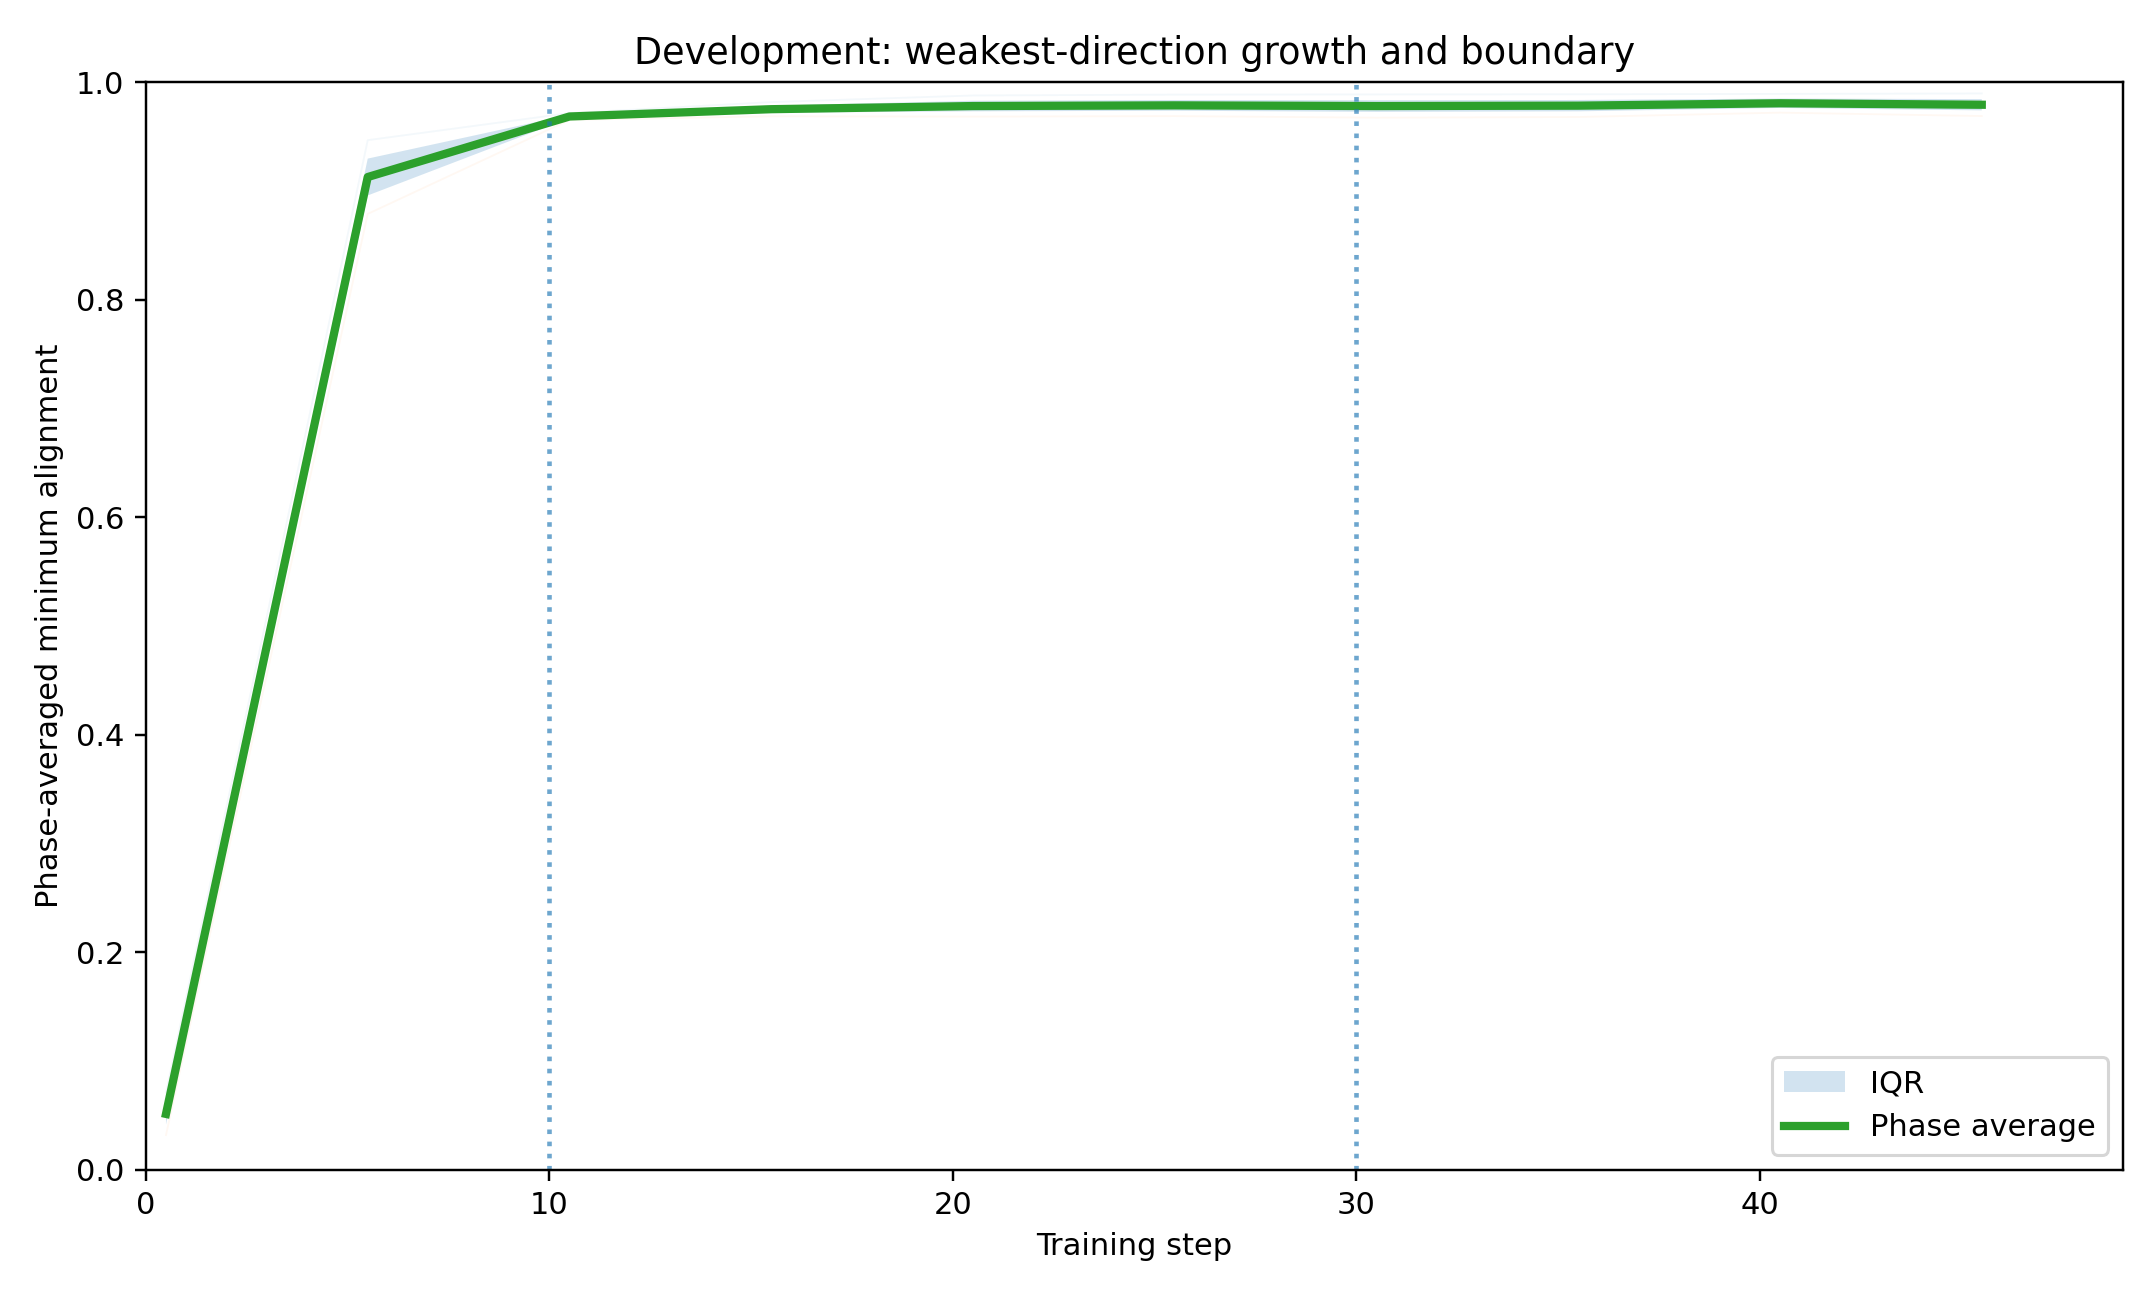

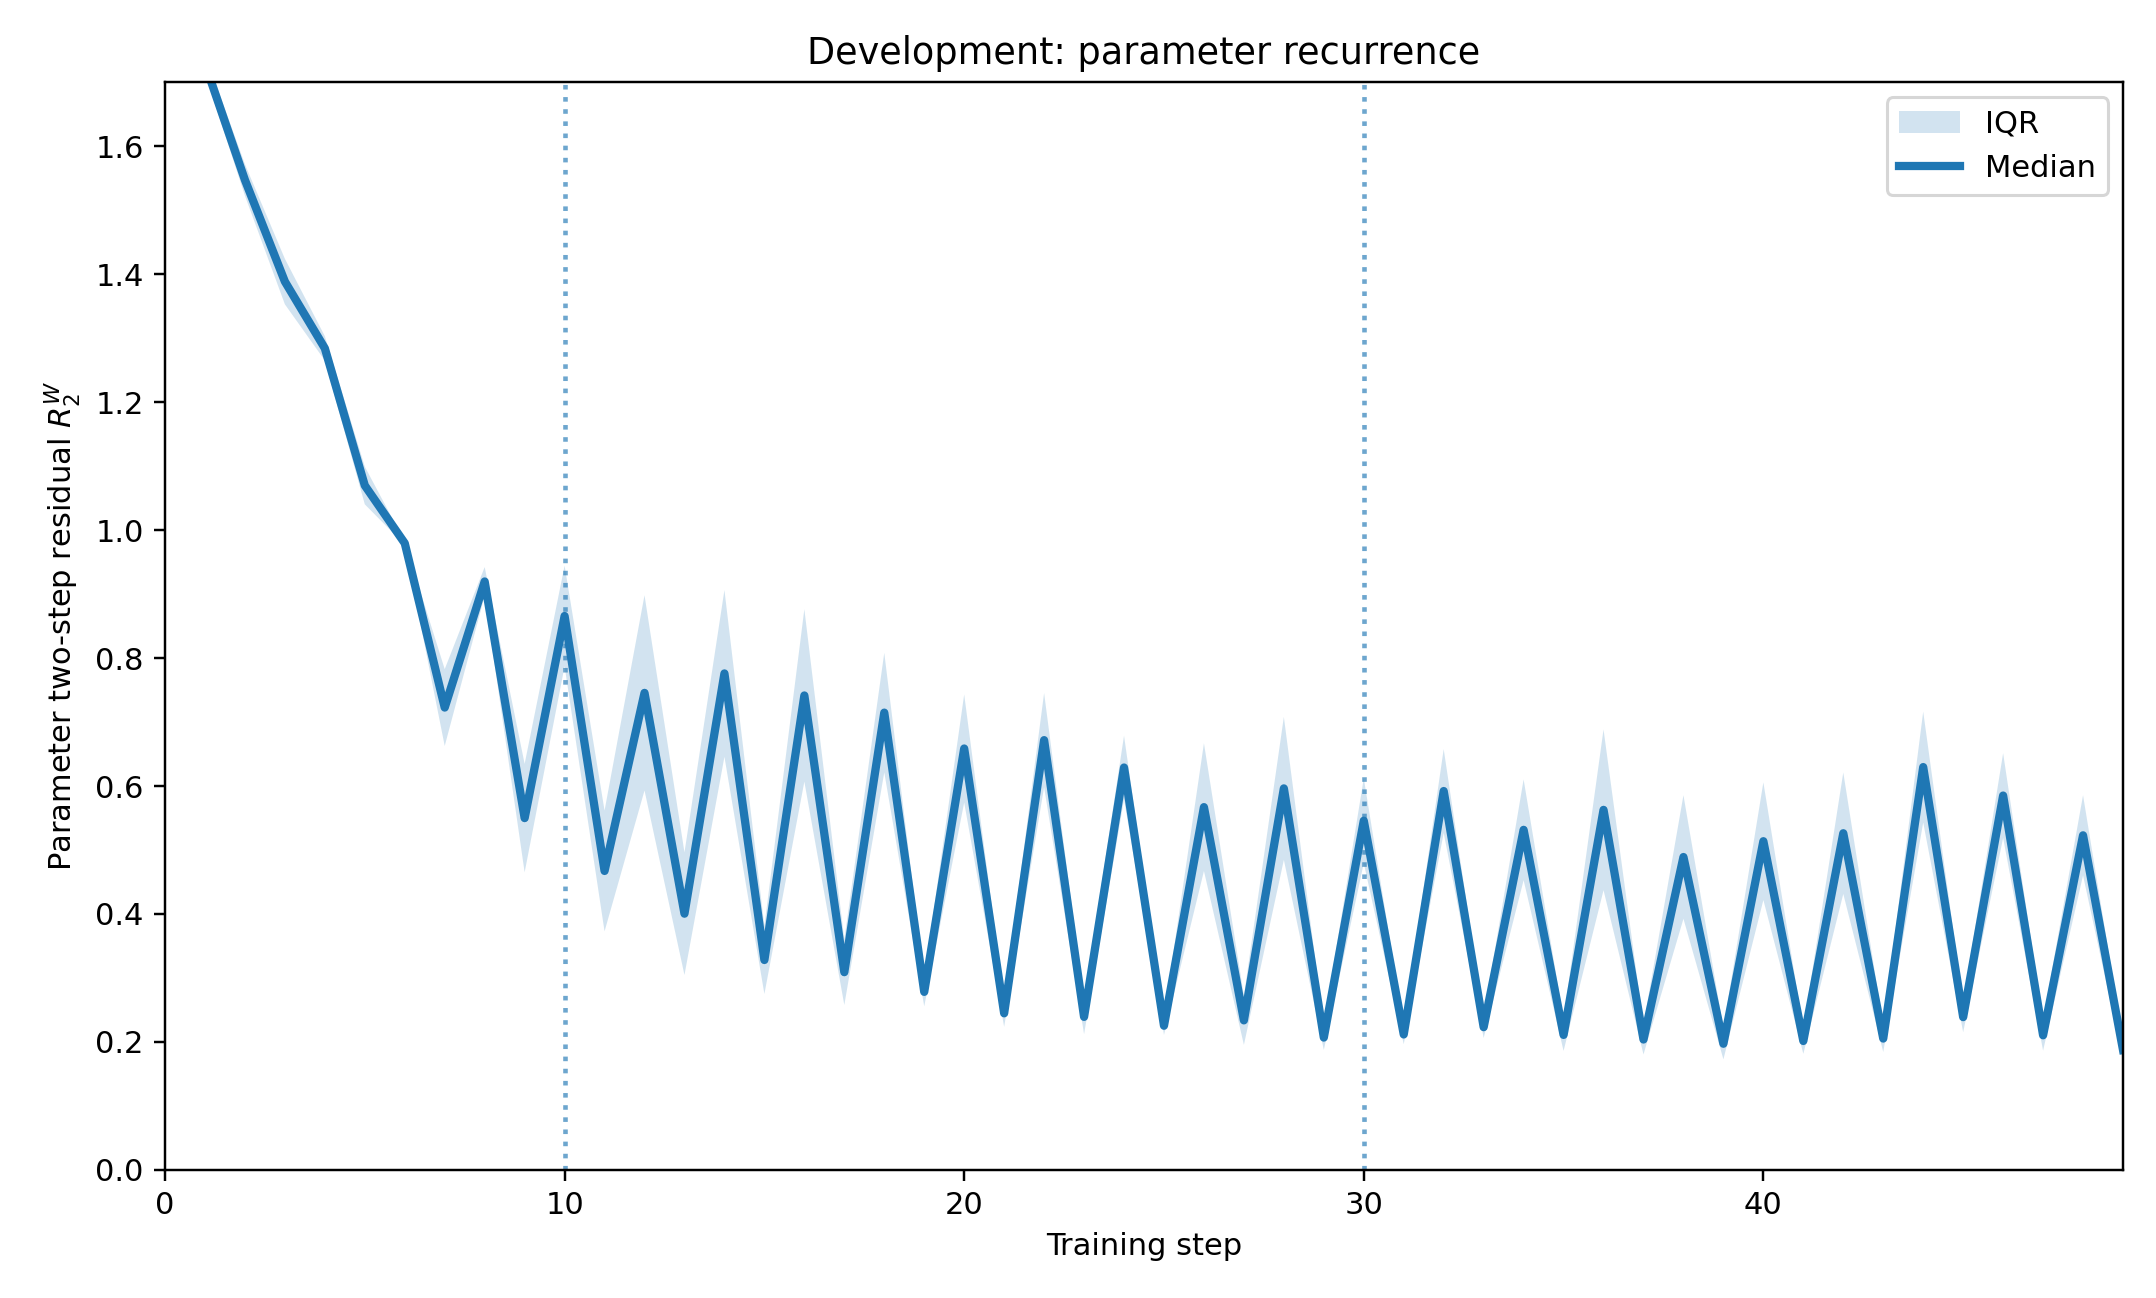

In [6]:
analysis_dir = analysis_outputs["analysis_dir"]
for group in groups:
    for filename in [
        f"{group}_loss_cycle.png",
        f"{group}_mean_alignment_two_phases.png",
        f"{group}_min_alignment_two_phases.png",
        f"{group}_mean_alignment_phase_average.png",
        f"{group}_min_alignment_phase_average.png",
        f"{group}_two_step_residual.png",
    ]:
        path = analysis_dir / filename
        if path.exists():
            display(Image(filename=str(path)))

## 5. Optional fixed-learning-rate sweep

In [7]:
RUN_ETA_SWEEP = False
ETA_GRID = [0.4, 0.5, 0.6, 0.7, 0.8]

if RUN_ETA_SWEEP:
    sweep_config = copy.deepcopy(config)
    sweep_config["output"]["experiment_name"] = f"notebook_{PRESET}_sweep"
    sweep_table = mpm.sweep_learning_rates(
        sweep_config,
        ETA_GRID,
        group="development",
        force=FORCE_RERUN,
    )
    display(sweep_table)
else:
    print("Set RUN_ETA_SWEEP=True to run the sweep.")

Set RUN_ETA_SWEEP=True to run the sweep.


The teacher basis is drawn independently in PCA coordinates. Whitening controls covariance but does not make the empirical MNIST distribution Gaussian. The task still uses teacher-generated targets.